# UNIDAD 3: Variables Aleatorias Discretas y Distribuciones de Probabilidad

**Duración:** 2 semanas (12 horas)

**Curso:** Probabilidad y Estadística Inferencial

**Institución:** Universidad de la Ciénega del Estado de Michoacán de Ocampo (UCEMICH)

**Profesor:** Luis José Yudico Anaya

**Carrera:** Ingeniería en Nanotecnología

**Nivel:** Tercer Semestre

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Multiagent-AI-Lab/Probability-Statistics-Agentic-AI-Core/blob/master/notebooks/UNIDAD_3_VARIABLES_ALEATORIAS_DISCRETAS.ipynb)

In [1]:
import os
import sys
from pathlib import Path

if 'google.colab' in sys.modules:
    repo_dir = "Probability-Statistics-Agentic-AI-Core"
    if not os.path.exists(repo_dir):
        !git clone -q https://github.com/Multiagent-AI-Lab/{repo_dir}.git
    os.chdir(repo_dir)
    %pip install -q -r requirements.txt
else:
    # Entorno local: ubicar la raiz del repo subiendo desde el cwd
    # (donde se lanzo Jupyter) y ponerla en sys.path para que
    # `from src.multiagent_core...` resuelva sin importar la carpeta actual.
    _raiz = next(
        (p for p in (Path.cwd(), *Path.cwd().parents)
         if (p / "src" / "multiagent_core").is_dir()),
        Path.cwd(),
    )
    if str(_raiz) not in sys.path:
        sys.path.insert(0, str(_raiz))


## Prerequisitos de esta unidad

- **Teorema de Bayes y Probabilidad Condicional** (Unidad 2) — se reutiliza al interpretar la PMF de una variable aleatoria condicionada a un evento observado.
- **Ciclo de Verificación Triple** (ver `GOVERNANCE.md`) — como en todas las unidades del curso, cada concepto con forma cerrada se verifica primero simbólicamente (SymPy) y luego se reproduce con las herramientas de producción (SciPy/statsmodels) antes de interpretarse.

## 1. Fundamentación Teórica y Conceptos Clave

En la teoría de la probabilidad y la ingeniería, una **Variable Aleatoria Discreta (VAD)** es una función determinista $X: \Omega \rightarrow \mathbb{R}$ que asigna un valor real a cada resultado de un espacio muestral $\Omega$, de modo que el rango de valores $R_X = \{x_1, x_2, x_3, \dots\}$ es un conjunto finito o infinito contable.

### 1.1 Función de Masa de Probabilidad (PMF) y Propiedades
La **Función de Masa de Probabilidad (PMF)** $p_X(x) = P(X = x)$ especifica la probabilidad exacta de que la variable aleatoria tome el valor $x$. Toda PMF válida satisface dos propiedades axiomáticas:

1. **No Negatividad**: $p_X(x) \ge 0$ para todo $x \in R_X$.
2. **Normalización Total**:
   $$\sum_{x \in R_X} p_X(x) = 1$$

### 1.2 Función de Distribución Acumulada (CDF)
La **Función de Distribución Acumulada (CDF)** $F_X(x)$ se define como la probabilidad de que $X$ tome un valor menor o igual a $x$:

$$F_X(x) = P(X \le x) = \sum_{x_k \le x} p_X(x_k)$$

Propiedades clave de la CDF discreta:
* Es una función escalonada (discontinua a la derecha), con saltos de altura $p_X(x_k)$ en cada valor soporte $x_k$.
* $\lim_{x \to -\infty} F_X(x) = 0$ y $\lim_{x \to +\infty} F_X(x) = 1$.
* Cálculo de probabilidad de intervalos: $P(a < X \le b) = F_X(b) - F_X(a)$.

### 1.3 Valor Esperado ($\mathbb{E}[X]$), Varianza ($\text{Var}(X)$) y Momentos
* **Valor Esperado (Media)**:
  $$\mathbb{E}[X] = \mu = \sum_{x \in R_X} x \cdot p_X(x)$$
* **Varianza**:
  $$\text{Var}(X) = \sigma^2 = \mathbb{E}[(X - \mu)^2] = \sum_{x \in R_X} (x - \mu)^2 p_X(x) = \mathbb{E}[X^2] - (\mathbb{E}[X])^2$$
* **Desviación Estándar**: $\sigma = \sqrt{\text{Var}(X)}$.

## 2. Familias Principales de Distribuciones Discretas

### 2.1 Distribución Bernoulli ($X \sim \text{Bernoulli}(p)$)
Modela un único ensayo aleatorio binario con probabilidad de éxito $p$ ($X=1$) y fracaso $q = 1-p$ ($X=0$).
* PMF: $P(X = x) = p^x (1-p)^{1-x}, \quad x \in \{0, 1\}$.
* Esperanza: $\mathbb{E}[X] = p$, Varianza: $\text{Var}(X) = p(1-p)$.

### 2.2 Distribución Binomial ($X \sim \text{Binomial}(n, p)$)
Número de éxitos en $n$ ensayos independientes e idénticamente distribuidos de Bernoulli.
* PMF:
  $$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}, \quad k \in \{0, 1, 2, \dots, n\}$$
* Esperanza: $\mathbb{E}[X] = n p$, Varianza: $\text{Var}(X) = n p (1-p)$.

### 2.3 Distribución de Poisson ($X \sim \text{Poisson}(\lambda)$)
Modela la ocurrencia de eventos raros en un intervalo continuo de tiempo o espacio, con tasa media $\lambda > 0$.
* PMF:
  $$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}, \quad k \in \{0, 1, 2, \dots\}$$
* Esperanza: $\mathbb{E}[X] = \lambda$, Varianza: $\text{Var}(X) = \lambda$.

### 2.4 Distribución Geométrica ($X \sim \text{Geométrica}(p)$)
Número de ensayos independientes de Bernoulli hasta obtener el **primer éxito**.
* PMF: $P(X = k) = (1-p)^{k-1} p, \quad k \in \{1, 2, 3, \dots\}$.
* Esperanza: $\mathbb{E}[X] = \frac{1}{p}$, Varianza: $\text{Var}(X) = \frac{1-p}{p^2}$.

### 2.5 Distribución Binomial Negativa ($X \sim \text{BinomialNegativa}(r, p)$)
Número de fracasos $k$ antes de observar el $r$-ésimo éxito.
* PMF:
  $$P(K = k) = \binom{k + r - 1}{k} p^r (1-p)^k, \quad k \in \{0, 1, 2, \dots\}$$
* Esperanza: $\mathbb{E}[K] = \frac{r(1-p)}{p}$, Varianza: $\text{Var}(K) = \frac{r(1-p)}{p^2}$.

### 2.6 Distribución Hipergeométrica ($X \sim \text{Hipergeométrica}(N, K, n)$)
Muestreo **sin reemplazo** de una población finita $N$ que contiene $K$ elementos con la característica deseada.
* PMF:
  $$P(X = k) = \frac{\binom{K}{k} \binom{N-K}{n-k}}{\binom{N}{n}}$$

### 2.7 Distribución Uniforme Discreta ($X \sim \text{Uniforme}\{1,\dots,k\}$)
Modela un experimento donde cada uno de $k$ resultados posibles tiene exactamente la misma probabilidad de ocurrir.
* PMF: $P(X = x_i) = \dfrac{1}{k}, \quad x_i \in \{1, 2, \dots, k\}$.
* Esperanza: $\mathbb{E}[X] = \dfrac{k+1}{2}$, Varianza: $\text{Var}(X) = \dfrac{k^2-1}{12}$.

### 2.8 Distribución Multinomial ($X_1,\dots,X_k \sim \text{Multinomial}(n, p_1,\dots,p_k)$)
Generaliza la distribución Binomial a experimentos con más de dos resultados posibles por ensayo.
* PMF: $P(X_1=k_1,\dots,X_k=k_k) = \dfrac{n!}{k_1!\,k_2!\cdots k_k!}\, p_1^{k_1} p_2^{k_2} \cdots p_k^{k_k}$, con $\sum_i k_i = n$.
* Esperanza por componente: $\mathbb{E}[X_i] = np_i$, Desviación estándar: $\sigma_i = \sqrt{np_i(1-p_i)}$.

El siguiente árbol de decisión resume cómo elegir entre las cuatro familias discretas más frecuentes (2.1-2.4) según la pregunta que plantea el experimento:

```mermaid
graph TD
    Inicio["Experimento aleatorio discreto"]
    Inicio --> P1{"Un solo ensayo Bernoulli (exito/fracaso)?"}
    P1 -->|"Si"| Bernoulli["Distribucion Bernoulli(p)"]
    P1 -->|"No, son n ensayos independientes"| P2{"Que se cuenta?"}
    P2 -->|"Numero de exitos en n ensayos fijos"| Binomial["Distribucion Binomial(n, p)"]
    P2 -->|"Numero de eventos raros en un intervalo continuo (tiempo/espacio)"| Poisson["Distribucion de Poisson(lambda)"]
    P2 -->|"Numero de ensayos hasta el primer exito"| Geometrica["Distribucion Geometrica(p)"]

```

![Diagrama](../docs/images/UNIDAD_3_VARIABLES_ALEATORIAS_DISCRETAS_1.svg)


### 2.9 Profundización: PMF Completa, CDF y Aplicaciones por Dominio

Las subsecciones 2.1 a 2.8 dan la definición mínima de cada familia. Esta subsección profundiza las 8 distribuciones discretas del curso con su CDF explícita, código de comparación gráfica en `scipy.stats`, y ejemplos de uso concretos en **Nanotecnología**, **Inteligencia Artificial** y **Diseño de Experimentos (DOE)**.

#### 2.9.1 Distribución Bernoulli — Profundización

* **CDF**: $F(x) = 0$ si $x<0$; $F(x) = 1-p$ si $0\le x<1$; $F(x)=1$ si $x\ge 1$.
* Caso especial de la Binomial con $n=1$: `scipy.stats.bernoulli` es un atajo de `binom(n=1, p)`.

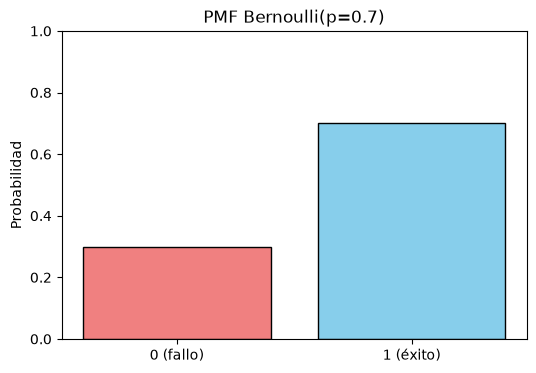

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bernoulli

## PMF de Bernoulli: probabilidad de que un nanosensor individual
## detecte correctamente un analito en una sola prueba (p=0.7)
p = 0.7
dist = bernoulli(p)
valores = [0, 1]
probabilidades = dist.pmf(valores)

plt.figure(figsize=(6, 4))
plt.bar(valores, probabilidades, color=["lightcoral", "skyblue"], edgecolor="black")
plt.xticks(valores, ["0 (fallo)", "1 (éxito)"])
plt.title(f"PMF Bernoulli(p={p})")
plt.ylabel("Probabilidad")
plt.ylim(0, 1)
plt.show()


**Nota de implementación**: como `bernoulli(p)` es exactamente `binom(n=1, p)`, ambas clases de `scipy.stats` son intercambiables — es común encontrar código que usa una u otra según la fuente. El siguiente fragmento reproduce el mismo resultado del bloque anterior usando `binom` directamente, para un nanosensor que detecta la presencia de un contaminante con probabilidad $p=0.9$ de operar correctamente en una sola prueba:

In [3]:
from scipy.stats import binom

p_exito = 0.9
x = 1  # exito: sensor no contaminado

probabilidad_pmf = binom.pmf(k=x, n=1, p=p_exito)         # equivalente a bernoulli.pmf(x, p_exito)
probabilidad_cdf = binom.cdf(k=x, n=1, p=p_exito)         # equivalente a bernoulli.cdf(x, p_exito)

print(f"P(X={x}) via binom(n=1): {probabilidad_pmf:.4f}")
print(f"F({x}) via binom(n=1):   {probabilidad_cdf:.4f}")


P(X=1) via binom(n=1): 0.9000
F(1) via binom(n=1):   1.0000


**Aplicaciones**: (1) *Nanotecnología*: resultado binario de una sola prueba de control de calidad sobre un nanodispositivo (pasa/no pasa la especificación de espesor). (2) *IA*: unidad básica de clasificación binaria — la salida de una neurona con activación sigmoide seguida de umbral se modela como Bernoulli con $p$ igual a la probabilidad predicha. (3) *DOE*: resultado de un único ensayo experimental con dos desenlaces posibles (p. ej., una réplica de síntesis produce o no el polimorfo deseado).

#### 2.9.2 Distribución Binomial — Profundización

* **CDF**: $F(x) = P(X\le x) = \sum_{i=0}^{\lfloor x\rfloor} \binom{n}{i}p^i(1-p)^{n-i}$.
* Suma de $n$ Bernoulli($p$) independientes: modela el conteo total de éxitos en un número fijo de ensayos idénticos.

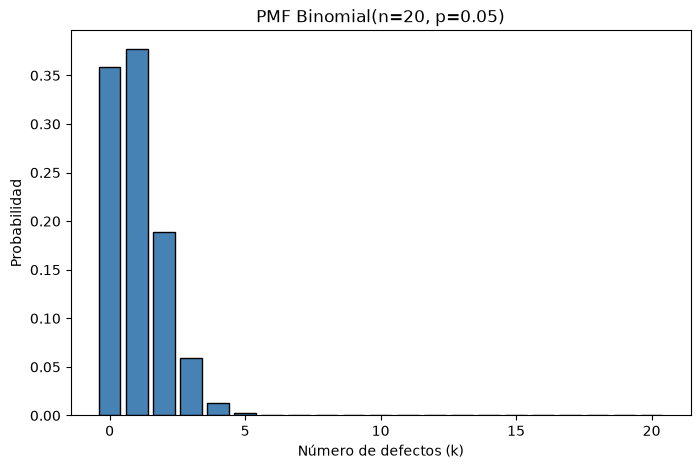

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

## PMF Binomial: numero de nanoparticulas defectuosas en un lote de
## n=20 con probabilidad de defecto p=0.05 por particula
n, p = 20, 0.05
dist = binom(n, p)
k = np.arange(0, n + 1)

plt.figure(figsize=(8, 5))
plt.bar(k, dist.pmf(k), color="steelblue", edgecolor="black")
plt.title(f"PMF Binomial(n={n}, p={p})")
plt.xlabel("Número de defectos (k)")
plt.ylabel("Probabilidad")
plt.show()


**Aplicaciones**: (1) *Nanotecnología*: número de nanopartículas defectuosas en un lote de tamaño fijo bajo una tasa de defecto constante por partícula — control de calidad de síntesis. (2) *IA*: número de predicciones correctas de un clasificador binario sobre un conjunto de prueba de tamaño fijo, bajo el supuesto de accuracy constante; fundamento del intervalo de confianza binomial para accuracy reportada. (3) *DOE*: número de réplicas exitosas de un experimento (p. ej., síntesis que alcanza la pureza objetivo) de un total de $n$ réplicas planeadas, para dimensionar el tamaño de muestra necesario.

#### 2.9.3 Distribución de Poisson — Profundización

* **CDF**: $F(x) = P(X\le x) = \sum_{i=0}^{\lfloor x\rfloor} \dfrac{\lambda^i e^{-\lambda}}{i!}$.
* Límite de la Binomial cuando $n\to\infty$, $p\to 0$ con $np=\lambda$ constante — modela conteos raros en un intervalo continuo de tiempo o espacio.

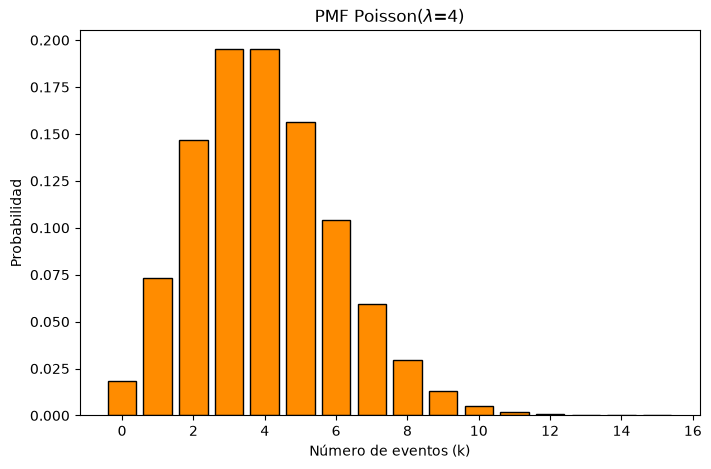

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

## PMF Poisson: numero de fallas de un nano-dispositivo por cada
## 1000 horas de operacion, con tasa promedio lambda=4
lam = 4
dist = poisson(lam)
k = np.arange(0, 16)

plt.figure(figsize=(8, 5))
plt.bar(k, dist.pmf(k), color="darkorange", edgecolor="black")
plt.title(f"PMF Poisson($\\lambda$={lam})")
plt.xlabel("Número de eventos (k)")
plt.ylabel("Probabilidad")
plt.show()


**Aplicaciones**: (1) *Nanotecnología*: número de fallas de un nano-dispositivo por unidad de tiempo de operación, o número de defectos puntuales por unidad de área en una película delgada. (2) *IA*: número de solicitudes que llega a un servidor de inferencia por unidad de tiempo, modelo base para dimensionar la capacidad de un sistema de predicción en producción. (3) *DOE*: número de eventos raros observados en un experimento de conteo (p. ej., número de núcleos de cristalización espontánea por unidad de volumen), fundamento de las pruebas de bondad de ajuste para procesos de conteo.

**Ejemplo — Análisis de doble cola de riesgo (dopaje de nanotransistores)**: en la fabricación de un nanotransistor, el número de átomos dopantes que terminan en el canal de conducción sigue $X \sim \text{Poisson}(\lambda=3)$ por unidad de volumen del canal. Un canal con **cero átomos dopantes** ($X=0$) es un fallo crítico (el transistor no conmuta); un canal con **6 o más** ($X\ge 6$) introduce variabilidad excesiva de voltaje umbral. A diferencia de los ejemplos anteriores, que evalúan un solo extremo de la distribución, aquí interesan **ambas colas simultáneamente**:

$$P(X=0) = \frac{3^0 e^{-3}}{0!} = e^{-3} \approx 0.0498, \qquad P(X\ge 6) = 1 - P(X\le 5) = 1 - F(5)$$

In [6]:
from scipy.stats import poisson

lam = 3
riesgo_canal_vacio = poisson.pmf(0, mu=lam)        # PMF en un extremo: fallo por ausencia de dopantes
riesgo_exceso_dopantes = 1 - poisson.cdf(5, mu=lam)  # 1 - CDF en el otro extremo: fallo por exceso

print(f"P(X=0) — riesgo de canal sin dopar:        {riesgo_canal_vacio:.4f}")
print(f"P(X>=6) — riesgo de exceso de dopantes:    {riesgo_exceso_dopantes:.4f}")
print(f"Riesgo total combinado (ambas colas):      {riesgo_canal_vacio + riesgo_exceso_dopantes:.4f}")


P(X=0) — riesgo de canal sin dopar:        0.0498
P(X>=6) — riesgo de exceso de dopantes:    0.0839
Riesgo total combinado (ambas colas):      0.1337


El patrón de combinar `pmf` en un extremo con `1 - cdf` en el otro —ya usado de forma parcial en la Sección 3.4 para $P(X\ge1)$— se generaliza aquí a un análisis de **dos colas de riesgo distintas** sobre la misma distribución, típico de especificaciones de manufactura con límites tanto inferior como superior.

#### 2.9.4 Distribución Geométrica — Profundización

* **CDF**: $F(x) = P(X\le x) = 1-(1-p)^{\lfloor x\rfloor}$.
* Modela el número de ensayos Bernoulli($p$) independientes hasta (e incluyendo) el primer éxito; análogo discreto de la propiedad de falta de memoria de la Exponencial.

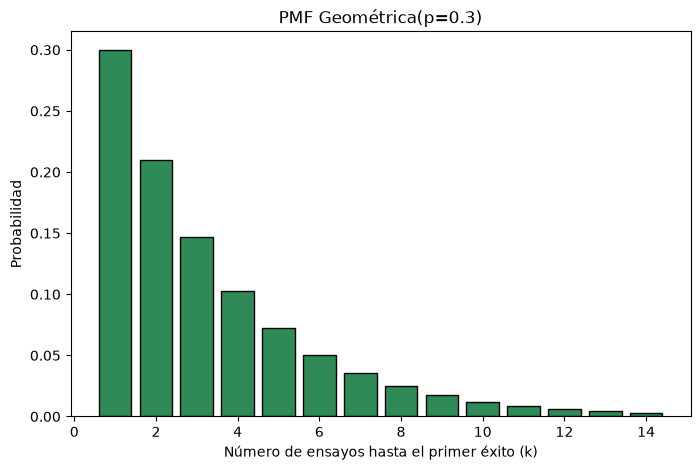

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import geom

## PMF Geometrica: numero de intentos de sintesis hasta obtener el
## primer lote de nanoparticulas dentro de especificacion (p=0.3)
p = 0.3
dist = geom(p)
k = np.arange(1, 15)

plt.figure(figsize=(8, 5))
plt.bar(k, dist.pmf(k), color="seagreen", edgecolor="black")
plt.title(f"PMF Geométrica(p={p})")
plt.xlabel("Número de ensayos hasta el primer éxito (k)")
plt.ylabel("Probabilidad")
plt.show()


**Aplicaciones**: (1) *Nanotecnología*: número de intentos de síntesis necesarios hasta obtener el primer lote de nanopartículas dentro de especificación, útil para estimar el costo esperado de un protocolo de bajo rendimiento. (2) *IA*: número de consultas a un modelo generativo hasta obtener la primera salida que pasa un filtro de calidad, relevante en técnicas de *rejection sampling*. (3) *DOE*: número de réplicas experimentales necesarias hasta observar el primer resultado exitoso, para planear el presupuesto de un experimento secuencial.

> ⚠️ **Cuidado con la convención de "fallas" vs. "ensayos"**: no todas las fuentes parametrizan la Geométrica igual. `scipy.stats.geom.pmf(x, p)` da la probabilidad de que el **ensayo número $x$** sea el primer éxito (soporte $x \in \{1,2,3,\dots\}$, la convención de esta lección). Otra convención común (usada, por ejemplo, en el paquete `stats` de R con `dgeom(k, p)`) da la probabilidad de observar exactamente $k$ **fallas antes** del éxito (soporte $k \in \{0,1,2,\dots\}$). Ambas describen el mismo fenómeno, pero difieren en un desplazamiento de índice: $k_{\text{fallas}} = x_{\text{ensayo}} - 1$, de modo que para obtener el mismo valor numérico hay que convertir explícitamente: `geom.pmf(k_fallas + 1, p)`. Confundir ambas convenciones al traducir una fórmula o código de una fuente a otra es un error silencioso — el código corre sin errores, pero calcula la probabilidad de un evento distinto (desplazado en 1) al que se pretendía.

#### 2.9.5 Distribución Binomial Negativa — Profundización

* **CDF**: sin forma cerrada simple; se evalúa numéricamente (`scipy.stats.nbinom.cdf`).
* Generaliza la Geométrica: modela el número de ensayos hasta obtener $r$ éxitos (no solo el primero). Para $r=1$ recupera la Geométrica.

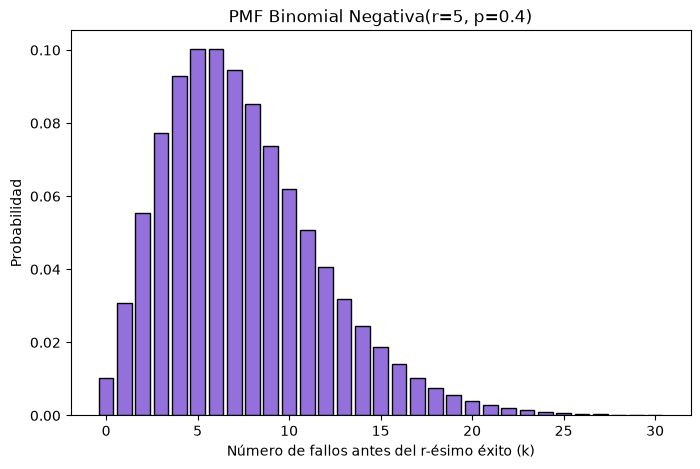

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import nbinom

## PMF Binomial Negativa: numero de lotes de sintesis necesarios
## hasta obtener r=5 lotes dentro de especificacion (p=0.4)
r, p = 5, 0.4
dist = nbinom(r, p)
k = np.arange(0, 31)

plt.figure(figsize=(8, 5))
plt.bar(k, dist.pmf(k), color="mediumpurple", edgecolor="black")
plt.title(f"PMF Binomial Negativa(r={r}, p={p})")
plt.xlabel("Número de fallos antes del r-ésimo éxito (k)")
plt.ylabel("Probabilidad")
plt.show()


**Aplicaciones**: (1) *Nanotecnología*: número de lotes de síntesis necesarios hasta acumular $r$ lotes dentro de especificación, para planificar la producción de un número fijo de muestras válidas. (2) *IA*: modelado de conteos con sobre-dispersión (varianza mayor que la media) en datos de conteo del mundo real, donde la Poisson resulta demasiado restrictiva — común en modelos de recuento de eventos raros con heterogeneidad. (3) *DOE*: número de réplicas experimentales necesarias hasta acumular un número objetivo de resultados exitosos, extendiendo el caso geométrico a metas de más de un éxito.

#### 2.9.6 Distribución Hipergeométrica — Profundización

* **CDF**: $F(x) = \sum_{j=0}^{\lfloor x\rfloor} \dfrac{\binom{K}{j}\binom{N-K}{n-j}}{\binom{N}{n}}$.
* A diferencia de la Binomial, modela muestreo **sin reemplazo** de una población finita — las probabilidades cambian con cada extracción.

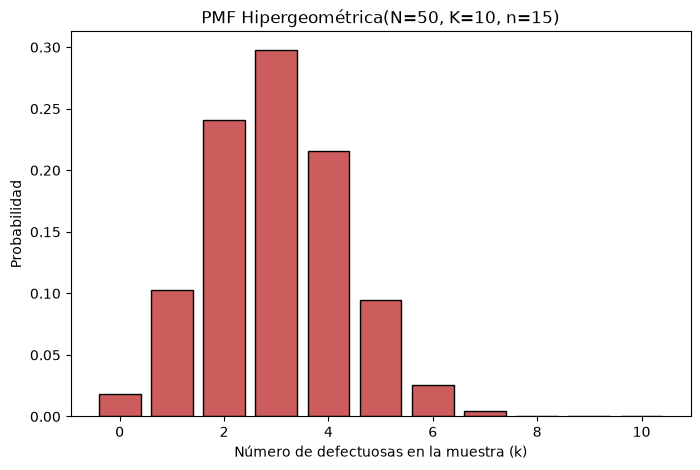

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import hypergeom

## PMF Hipergeometrica: numero de nanoparticulas defectuosas al
## extraer una muestra de n=15 de un lote finito N=50 con K=10 defectuosas
N, K, n = 50, 10, 15
dist = hypergeom(N, K, n)
k = np.arange(0, min(K, n) + 1)

plt.figure(figsize=(8, 5))
plt.bar(k, dist.pmf(k), color="indianred", edgecolor="black")
plt.title(f"PMF Hipergeométrica(N={N}, K={K}, n={n})")
plt.xlabel("Número de defectuosas en la muestra (k)")
plt.ylabel("Probabilidad")
plt.show()


**Aplicaciones**: (1) *Nanotecnología*: número de nanopartículas defectuosas al extraer una muestra de inspección de un lote finito de producción, sin reponer las unidades muestreadas — el caso realista de control de calidad destructivo. (2) *IA*: muestreo de un conjunto de datos finito (p. ej., seleccionar un subconjunto de validación sin reemplazo de un dataset fijo), relevante para el diseño de validación cruzada. (3) *DOE*: número de muestras con una característica de interés (p. ej., un lote de materia prima defectuoso) al extraer una muestra de auditoría de un envío finito, sin reposición.

#### 2.9.7 Distribución Uniforme Discreta — Profundización

* **CDF**: $F(x) = \dfrac{\lfloor x\rfloor - a + 1}{k}$ para $a\le x\le b$, con $k=b-a+1$.
* Todos los $k$ valores del rango $\{a,\dots,b\}$ son igualmente probables — es el generador discreto base para simulación por muestreo aleatorio simple.

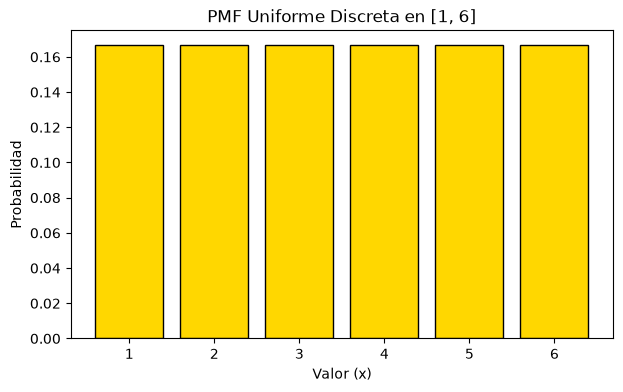

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import randint

## PMF Uniforme Discreta: seleccion aleatoria de una posicion de
## un chip de 6 sitios de reaccion en un ensayo de sintesis paralela
a, b = 1, 6
dist = randint(a, b + 1)
valores = np.arange(a, b + 1)

plt.figure(figsize=(7, 4))
plt.bar(valores, dist.pmf(valores), color="gold", edgecolor="black")
plt.title(f"PMF Uniforme Discreta en [{a}, {b}]")
plt.xlabel("Valor (x)")
plt.ylabel("Probabilidad")
plt.show()


**Aplicaciones**: (1) *Nanotecnología*: selección aleatoria de un sitio de reacción entre $k$ posiciones equivalentes en un chip de síntesis paralela, cuando no hay razón física para preferir una posición sobre otra. (2) *IA*: asignación aleatoria uniforme de ejemplos a particiones de entrenamiento/validación cuando se desea que cada partición tenga igual probabilidad de recibir cualquier ejemplo. (3) *DOE*: aleatorización del orden de corrida de los tratamientos de un experimento (randomización), un requisito metodológico estándar para evitar sesgos por efectos temporales.

#### 2.9.8 Distribución Multinomial — Profundización

* Generaliza la Binomial a $k>2$ categorías; no tiene una CDF cerrada de uso práctico — se trabaja directamente con la PMF conjunta o vía simulación.
* Cada componente marginal $X_i$ es por sí sola Binomial($n$, $p_i$), pero las componentes no son independientes entre sí (están ligadas por $\sum_i X_i = n$).

In [11]:
import numpy as np
from scipy.stats import multinomial

## PMF Multinomial: clasificacion de n=20 nanoparticulas en 3
## categorias de tamano (pequena, mediana, grande) segun el proceso
n = 20
probabilidades = [0.2, 0.5, 0.3]
dist = multinomial(n, probabilidades)

## Probabilidad de obtener exactamente 4 pequenas, 10 medianas, 6 grandes
conteo_observado = [4, 10, 6]
prob = dist.pmf(conteo_observado)
print(f"P(4 pequeñas, 10 medianas, 6 grandes) = {prob:.4f}")

## Esperanza por categoria: E[X_i] = n * p_i
esperanza = n * np.array(probabilidades)
print(f"Esperanza por categoría: {esperanza}")


P(4 pequeñas, 10 medianas, 6 grandes) = 0.0442
Esperanza por categoría: [ 4. 10.  6.]


**Aplicaciones**: (1) *Nanotecnología*: clasificación de un lote de $n$ nanopartículas en $k$ categorías de tamaño (pequeña/mediana/grande) según las probabilidades conocidas de un proceso de síntesis sol-gel. (2) *IA*: distribución de probabilidad de salida de un clasificador multiclase (capa *softmax*) sobre $k$ categorías — la Multinomial es la distribución muestral subyacente a los conteos de predicciones correctas por clase. (3) *DOE*: resultado de un experimento con más de dos desenlaces categóricos posibles por unidad experimental (p. ej., clasificar cada muestra en "aprobada", "reprocesable" o "rechazada"), base de las pruebas de bondad de ajuste $\chi^2$ sobre datos categóricos.

**Más allá de un solo punto: enumerar y comparar todos los resultados posibles.** El código de 2.9.8 evalúa la PMF en un único conteo observado $(4,10,6)$. Con frecuencia interesa además saber **qué otros resultados** son igual o más probables que el observado — por ejemplo, para juzgar si el conteo real de un lote es consistente con el proceso esperado. Esto requiere enumerar todas las combinaciones $(x_1,x_2,x_3)$ con $x_1+x_2+x_3=n$ y ordenarlas por probabilidad:

In [12]:
import numpy as np
import pandas as pd
from scipy.stats import multinomial

## Nanoreactor de sintesis sol-gel: n=20 nanoparticulas, 3 categorias de
## tamano con probabilidades del proceso (pequena, mediana, grande)
n = 20
probabilidades = [0.2, 0.5, 0.3]

resultados_validos = []
for x1 in range(n + 1):
    for x2 in range(n - x1 + 1):
        x3 = n - x1 - x2
        resultados_validos.append([x1, x2, x3])

resultados_array = np.array(resultados_validos)
pmf_valores = multinomial.pmf(x=resultados_array, n=n, p=probabilidades)

tabla = pd.DataFrame(resultados_array, columns=["pequeñas", "medianas", "grandes"])
tabla["pmf"] = pmf_valores
top_10 = tabla.sort_values(by="pmf", ascending=False).head(10)

print(f"Total de combinaciones válidas con suma {n}: {len(tabla)}")
print("\nTop 10 combinaciones más probables:")
print(top_10.to_string(index=False))


Total de combinaciones válidas con suma 20: 231

Top 10 combinaciones más probables:
 pequeñas  medianas  grandes      pmf
        4        10        6 0.044194
        3        11        6 0.040177
        4        11        5 0.040177
        3        10        7 0.037881
        4         9        7 0.037881
        5        10        5 0.035355
        5         9        6 0.035355
        3        12        5 0.033480
        3         9        8 0.028411
        4        12        4 0.027900


El resultado confirma que la combinación $(4,10,6)$ evaluada en 2.9.8 —que coincide exactamente con el valor esperado por categoría, $n\cdot p_i = (4,10,6)$— es precisamente la **moda** de la distribución multinomial: la más probable de las 231 combinaciones válidas para $n=20$. Este patrón de enumeración exhaustiva es la técnica correcta para responder preguntas del tipo "¿qué tan inusual es este conteo observado?", en vez de solo reportar su probabilidad puntual sin contexto de las alternativas.

## 3. Ejemplo Analítico Paso a Paso: Inspección Nanotecnológica de Micro-sensores

### 3.1 Contexto Aplicado en Nanotecnología
En una sala limpia de fabricación de nano-sensores piezoresistivos para dispositivos médicos implantables, la probabilidad de que una unidad presente una micro-grieta estructural en el diafragma de silicio durante la etapa de grabado químico es $p = 0.05$. Un ingeniero en control de calidad selecciona una muestra aleatoria de $n = 20$ nano-sensores del lote de producción diaria.

Determine:
1. La probabilidad exacta de encontrar exactamente 2 nano-sensores defectuosos en la muestra.
2. La probabilidad de encontrar al menos 1 nano-sensor defectuoso.
3. El número esperado y la desviación estándar de nano-sensores defectuosos.

### 3.2 Paso 1: Identificación del Modelo y Parámetros
El conteo de nano-sensores defectuosos en $n=20$ ensayos independientes con $p=0.05$ sigue una distribución Binomial:
$$X \sim \text{Binomial}(n = 20, p = 0.05)$$

### 3.3 Paso 2: Cálculo de $P(X = 2)$
$$P(X = 2) = \binom{20}{2} (0.05)^2 (0.95)^{18}$$
$$\binom{20}{2} = \frac{20 \times 19}{2} = 190$$
$$(0.05)^2 = 0.0025, \quad (0.95)^{18} \approx 0.397214$$
$$\boxed{P(X = 2) = 190 \times 0.0025 \times 0.397214 \approx 0.18868 \quad (18.87\%)}$$

### 3.4 Paso 3: Cálculo de $P(X \ge 1)$ por Complemento
$$P(X \ge 1) = 1 - P(X = 0) = 1 - \binom{20}{0} (0.05)^0 (0.95)^{20}$$
$$(0.95)^{20} \approx 0.358486$$
$$\boxed{P(X \ge 1) = 1 - 0.358486 = 0.64151 \quad (64.15\%)}$$

### 3.5 Paso 4: Esperanza y Desviación Estándar
$$\mathbb{E}[X] = n p = 20 \times 0.05 = \boxed{1.0 \text{ nano-sensor}}$$
$$\text{Var}(X) = n p (1-p) = 20 \times 0.05 \times 0.95 = 0.95 \implies \sigma = \sqrt{0.95} \approx \boxed{0.9747\text{ nano-sensores}}$$

### 3.6 Prueba Unitaria con pytest

Se contrasta cada resultado derivado a mano (combinatoria + PMF Binomial) contra `scipy.stats.binom`, que calcula la misma fórmula sin riesgo de error aritmético humano:

In [13]:
import ipytest
import pytest
from scipy.stats import binom

ipytest.autoconfig()

n, p = 20, 0.05


def test_probabilidad_de_exactamente_2_defectuosos():
    assert binom.pmf(2, n, p) == pytest.approx(0.18868, rel=1e-3)


def test_probabilidad_de_al_menos_1_defectuoso_por_complemento():
    prob_al_menos_uno = 1 - binom.pmf(0, n, p)
    assert prob_al_menos_uno == pytest.approx(0.64151, rel=1e-3)


def test_esperanza_y_varianza_binomial():
    assert n * p == pytest.approx(1.0)
    assert n * p * (1 - p) == pytest.approx(0.95)


ipytest.run("-vv")


======================================= test session starts =======================================
platform win32 -- Python 3.11.15, pytest-9.1.1, pluggy-1.6.0 -- C:\Users\ljyud\anaconda3\envs\ia_stats\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\ljyud\Desktop\IA UCEMICH\PROBABILIDAD Y ESTADÍSTICA\notebooks
plugins: anyio-4.14.2, mock-3.15.1
collecting ... 

collected 3 items

t_7f1d9c35b9e847d3b0cbcc0e7e7279b4.py::test_probabilidad_de_exactamente_2_defectuosos 

PASSED [ 33%]


t_7f1d9c35b9e847d3b0cbcc0e7e7279b4.py::test_probabilidad_de_al_menos_1_defectuoso_por_complemento 

PASSED [ 66%]


t_7f1d9c35b9e847d3b0cbcc0e7e7279b4.py::test_esperanza_y_varianza_binomial 

PASSED             [100%]



======================================== 3 passed in 0.06s ========================================


<ExitCode.OK: 0>

## 4. Código de Verificación Simbólica (SymPy)

Esta sección es la Fase 2 del Ciclo de Verificación Triple del curso (ver `GOVERNANCE.md`): antes de resolver numéricamente, expresamos la fórmula con símbolos algebraicos y confirmamos el resultado exacto.

In [14]:
import sympy as sp
from IPython.display import display, Math

## 1. Definición de símbolos
n = sp.Symbol('n', positive=True, integer=True)
k = sp.Symbol('k', integer=True)
p = sp.Symbol('p', positive=True)

## 2. Expresión simbólica de la PMF Binomial y Esperanza
pmf_binomial = sp.binomial(n, k) * (p**k) * ((1 - p)**(n - k))
esperanza_expr = sp.Sum(k * pmf_binomial, (k, 0, n))

display(Math(fr"\text{{PMF Binomial Simbólica: }} P(X = k) = {sp.latex(pmf_binomial)}"))

## 3. Sustitución de los parámetros de la inspección nanotecnológica (n=20, p=0.05, k=2)
valores = {n: 20, p: sp.Rational(5, 100), k: 2}
prob_exacta = pmf_binomial.subs(valores)
prob_decimal = float(prob_exacta)

display(Math(fr"\text{{Resultado Exacto }} P(X=2): {sp.latex(prob_exacta)} = \boxed{{{prob_decimal:.5f}}}"))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 5. Solución Computacional en Python (SciPy & Statsmodels)

--- RESULTADOS SCI PY STATS (BINOMIAL) ---
P(X = 2) exacta:          0.18868
P(X >= 1) acumulada:      0.64151
Esperanza teórica E[X]:   1.00
Desviación Estándar SD:   0.9747


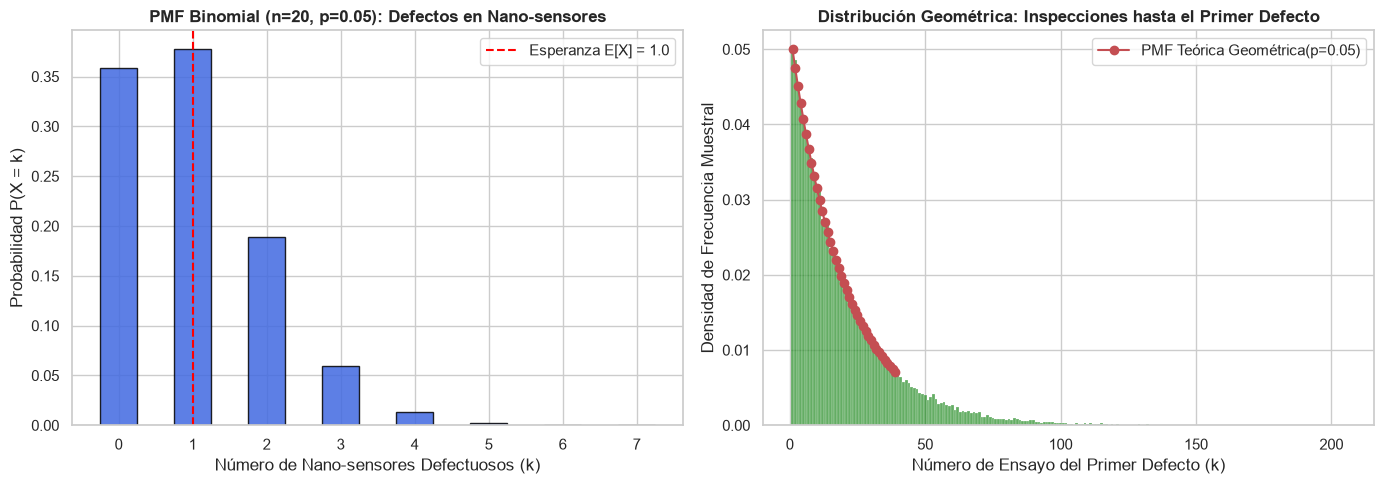

P(4 pequeñas, 10 medianas, 6 grandes) = 0.044194
Número esperado por categoría: [4.0, 10.0, 6.0]


In [15]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

## Configuración visual profesional
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## --- PARTE A: Cálculo Exacto con scipy.stats.binom ---
n_val = 20
p_val = 0.05

pmf_k2 = stats.binom.pmf(k=2, n=n_val, p=p_val)
cdf_k0 = stats.binom.cdf(k=0, n=n_val, p=p_val)
prob_al_menos_1 = 1 - cdf_k0

print("--- RESULTADOS SCI PY STATS (BINOMIAL) ---")
print(f"P(X = 2) exacta:          {pmf_k2:.5f}")
print(f"P(X >= 1) acumulada:      {prob_al_menos_1:.5f}")
print(f"Esperanza teórica E[X]:   {stats.binom.mean(n=n_val, p=p_val):.2f}")
print(f"Desviación Estándar SD:   {stats.binom.std(n=n_val, p=p_val):.4f}")

## --- PARTE B: Comparación de Familias Discretas (Binomial vs Poisson vs Geométrica) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

## Gráfico 1: PMF de Binomial n=20, p=0.05
k_range = np.arange(0, 8)
pmf_vals = stats.binom.pmf(k_range, n=n_val, p=p_val)

axes[0].bar(k_range, pmf_vals, color='royalblue', alpha=0.85, edgecolor='black', width=0.5)
axes[0].axvline(x=1.0, color='red', linestyle='--', label='Esperanza E[X] = 1.0')
axes[0].set_title("PMF Binomial (n=20, p=0.05): Defectos en Nano-sensores", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Número de Nano-sensores Defectuosos (k)")
axes[0].set_ylabel("Probabilidad P(X = k)")
axes[0].legend()

## Gráfico 2: Simulación de Distribución Geométrica (Ensayos hasta primer defecto)
p_geom = 0.05
muestras_geom = stats.geom.rvs(p=p_geom, size=50_000, random_state=42)

sns.histplot(muestras_geom, discrete=True, stat="density", color="forestgreen", alpha=0.7, ax=axes[1])
x_geom = np.arange(1, 40)
pmf_geom_teorica = stats.geom.pmf(x_geom, p=p_geom)
axes[1].plot(x_geom, pmf_geom_teorica, 'ro-', lw=1.5, label='PMF Teórica Geométrica(p=0.05)')
axes[1].set_title("Distribución Geométrica: Inspecciones hasta el Primer Defecto", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Número de Ensayo del Primer Defecto (k)")
axes[1].set_ylabel("Densidad de Frecuencia Muestral")
axes[1].legend()

plt.tight_layout()
plt.show()

## --- PARTE C: Distribución Multinomial — Clasificación de Nanopartículas por Tamaño ---
## En síntesis sol-gel de nanopartículas de óxido metálico, se clasifican en 3 categorías
## de diámetro: pequeña (<10nm), mediana (10-30nm), grande (>30nm), con probabilidades
## conocidas del proceso. Crítico para el control de calidad en nanotecnología.
from scipy.stats import multinomial

n_lote = 20
p_categorias = [0.2, 0.5, 0.3]  # P(pequeña), P(mediana), P(grande)

## Probabilidad de obtener exactamente 4 pequeñas, 10 medianas, 6 grandes
conteo_observado = [4, 10, 6]
prob_conteo = multinomial.pmf(conteo_observado, n=n_lote, p=p_categorias)
print(f"P(4 pequeñas, 10 medianas, 6 grandes) = {prob_conteo:.6f}")

## Esperanza por categoría
esperanza = [n_lote * p for p in p_categorias]
print(f"Número esperado por categoría: {esperanza}")


## 6. Interpretación Post-Gráfico & Diccionario de Variables

### 6.1 Interpretación de Resultados Computacionales
1. **Asimetría Positiva en Eventos Raros**: La PMF de la distribución binomial para $n=20, p=0.05$ exhibe una fuerte asimetría a la derecha concentrada en $k=0$ ($35.8\%$) y $k=1$ ($37.7\%$). La probabilidad de obtener más de 3 nano-sensores defectuosos es prácticamente nula ($< 1.6\%$).
2. **Comportamiento Memoria Geométrica**: La simulación de $50,000$ réplicas geométricas muestra que el número esperado de inspecciones necesarias para detectar el primer defecto es $\mathbb{E}[K] = 1/0.05 = 20$ ensayos.
3. **Clasificación Multinomial de Nanopartículas por Tamaño**: El resultado computacional de PARTE C confirma que, para un lote de $n=20$ nanopartículas sintetizadas por vía sol-gel con probabilidades de categoría $p = (0.2, 0.5, 0.3)$, el conteo esperado por categoría de diámetro es de $4$ nanopartículas pequeñas ($<10$ nm), $10$ medianas ($10$–$30$ nm) y $6$ grandes ($>30$ nm) — exactamente el escenario evaluado, lo que explica por qué su probabilidad puntual es la moda de la distribución multinomial. En control de calidad de nanomateriales, esta distribución conjunta permite estimar la probabilidad de que un lote de síntesis cumpla simultáneamente los tres rangos de tamaño objetivo, en lugar de evaluar cada categoría de forma aislada como haría una binomial marginal; esto es clave para ajustar los parámetros del proceso sol-gel (pH, temperatura, tiempo de reacción) cuando la distribución de tamaños observada se desvía de la especificación de diseño del nanomaterial.

### 6.2 Diccionario de Variables de la Unidad

Notación general introducida en las Secciones 1-2, independiente del ejemplo aplicado específico:

* $X$: variable aleatoria discreta genérica; $\Omega$: espacio muestral; $R_X$: rango (soporte) de $X$.
* $p_X(x)$: función de masa de probabilidad (PMF), $p_X(x) = P(X=x)$.
* $F_X(x)$: función de distribución acumulada (CDF), $F_X(x) = P(X \le x)$.
* $\mathbb{E}[X]$, $\mu$: valor esperado (media) de $X$.
* $\text{Var}(X)$, $\sigma^2$: varianza de $X$; $\sigma$: desviación estándar ($\sigma=\sqrt{\text{Var}(X)}$).
* $p$: probabilidad de éxito de un ensayo (Bernoulli, Binomial, Geométrica, Binomial Negativa); $q=1-p$: probabilidad de fracaso (Bernoulli).
* $n$: número de ensayos independientes (Binomial), o tamaño de la muestra extraída (Hipergeométrica), o número total de ensayos por experimento (Multinomial).
* $k$, $x$: valor puntual sobre el que se evalúa la PMF/CDF de una distribución discreta (número de éxitos, de fallos o de ensayos, según la familia).
* $\lambda$: tasa media de ocurrencia de eventos por intervalo (Poisson), $\lambda>0$.
* $r$: número objetivo de éxitos a acumular (Binomial Negativa).
* $N$: tamaño de la población finita; $K$: número de elementos con la característica de interés en la población (Hipergeométrica; distinta de la $K$ usada como variable aleatoria de conteo de fallos en la Sección 6.3).
* $a, b$: extremos del rango de valores igualmente probables; $k=b-a+1$: número de valores posibles (Uniforme Discreta).
* $X_1,\dots,X_k$: componentes del vector aleatorio conjunto; $p_1,\dots,p_k$ (con $\sum_i p_i=1$): probabilidades por categoría; $k_1,\dots,k_k$ (con $\sum_i k_i=n$): conteos observados por categoría (Multinomial).

### 6.3 Diccionario de Variables Nanotecnológicas del Ejemplo Aplicado
* $X$: Variable aleatoria discreta que representa el número de nano-sensores defectuosos.
* $n$: Tamaños del lote inspeccionado ($n=20$).
* $p$: Probabilidad individual de falla microscópica por grabado de silicio ($p=0.05$).
* $\lambda$: Tasa media de ocurrencia de defectos en procesos continuos de litografía (Poisson).
* $K$: Número de ensayos independientes hasta observar la primera falla (Geométrica).

## 7. Módulo de Simulación: Algoritmo de Generación Estocástica de Variables Discretas

### 7.1 Algoritmo General de Inversión por Suma Acumulada
Dada una variable aleatoria discreta $X$ con PMF $P(X = x_k) = p_k$:
1. Generar $U \sim \text{Uniforme}(0, 1)$.
2. Seleccionar el menor índice $k$ tal que $\sum_{j=1}^k p_j \ge U$.

### 7.2 Simulación Estocástica en Python de Fallas Poisson

In [16]:
import numpy as np
import scipy.stats as stats

np.random.seed(123)
N_sim = 50_000
lam = 4.5  # Promedio de micro-defectos por oblea de silicio
muestras_poisson = stats.poisson.rvs(mu=lam, size=N_sim)

print(f"Promedio Muestral de Defectos Simulado: {np.mean(muestras_poisson):.4f} | Teórico: {lam}")
print(f"Varianza Muestral Simulada:             {np.var(muestras_poisson):.4f} | Teórica: {lam}")


Promedio Muestral de Defectos Simulado: 4.5088 | Teórico: 4.5
Varianza Muestral Simulada:             4.5286 | Teórica: 4.5


## 8. Referencia Avanzada (Opcional)

Este curso (tercer semestre) trata a las variables aleatorias discretas con herramientas de cálculo elemental. Para quien desee profundizar hacia un tratamiento formal medida-teórico (variables aleatorias como funciones medibles, espacios de probabilidad abstractos), el curso de posgrado **MIT 6.436J — Fundamentals of Probability** (Prof. Yury Polyanskiy) cubre este mismo tema en sus *Lecture Notes* 4–6, con los prerrequisitos de análisis real y teoría de la medida que ese enfoque exige: [ocw.mit.edu/courses/6-436j-fundamentals-of-probability-fall-2018/pages/lecture-notes](https://ocw.mit.edu/courses/6-436j-fundamentals-of-probability-fall-2018/pages/lecture-notes/).

## Errores Comunes / Misconceptions

* **Error**: Confundir la PMF con la CDF — evaluar $P(X = k)$ cuando el problema pedía $P(X \le k)$ (o viceversa).
  **Correcto**: la PMF $p(k) = P(X=k)$ da la probabilidad de un valor puntual; la CDF $F(k) = P(X \le k) = \sum_{i \le k} p(i)$ acumula todas las probabilidades hasta $k$. Para "al menos" o "a lo más" siempre se necesita la CDF (o su complemento), no la PMF evaluada en un solo punto.

* **Error**: Asumir que la esperanza $\mathbb{E}[X]$ de una variable discreta debe coincidir con alguno de sus valores posibles.
  **Correcto**: $\mathbb{E}[X]$ es un promedio ponderado por probabilidades y puede caer entre valores posibles (p. ej. $\mathbb{E}[X] = 3.5$ para un dado justo, aunque 3.5 nunca es un resultado del lanzamiento).

* **Error**: Usar la aproximación Poisson de la Binomial ($\lambda = np$) en cualquier caso, sin verificar las condiciones de validez.
  **Correcto**: la aproximación solo es razonable cuando $n$ es grande, $p$ es pequeño y $np$ es moderado (regla práctica: $n \ge 20$ y $p \le 0.05$, o $np < 10$); fuera de ese régimen la Binomial y la Poisson difieren de forma apreciable, especialmente en las colas.

## Preguntas de Concepto

**Pregunta 1.** Un problema pide calcular la probabilidad de que una variable discreta $X$ tome "a lo más" el valor $k$. ¿Qué función se debe usar?

A) La PMF, $P(X = k)$, evaluada en $k$.
B) Cualquiera de las dos, dan el mismo resultado.
C) Ninguna; se necesita la función generadora de momentos.
D) La CDF, $F(k) = P(X \le k)$, que acumula las probabilidades hasta $k$.

**Pregunta 2.** Para un dado justo de 6 caras (valores 1 a 6), $\mathbb{E}[X] = 3.5$. ¿Qué implica esto sobre la esperanza de una variable aleatoria discreta?

A) Es un error de cálculo, la esperanza debe ser un valor posible de la variable.
B) La esperanza es un promedio ponderado por probabilidades y puede caer entre los valores posibles, sin ser en sí misma un resultado alcanzable.
C) Significa que el dado está cargado.
D) La esperanza solo puede tomar valores enteros en variables discretas.

**Pregunta 3.** ¿En qué condiciones es razonable aproximar una distribución Binomial mediante una Poisson con $\lambda = np$?

A) Siempre, sin importar los valores de $n$ y $p$.
B) Solo cuando $n$ es pequeño y $p$ es grande.
C) Cuando $n$ es grande, $p$ es pequeño y $np$ es moderado (p. ej. $n \ge 20$, $p \le 0.05$).
D) Nunca; Binomial y Poisson son incompatibles matemáticamente.

**Pregunta 4.** Una variable aleatoria Geométrica modela el número de intentos hasta el primer éxito. ¿Qué la distingue conceptualmente de una Binomial?

A) La Binomial cuenta éxitos en un número fijo de ensayos; la Geométrica cuenta ensayos hasta obtener el primer éxito (número de ensayos es la variable aleatoria).
B) Son exactamente la misma distribución con distinto nombre.
C) La Geométrica solo aplica a eventos continuos.
D) La Binomial no tiene un número fijo de ensayos, a diferencia de la Geométrica.

A continuación, verifica tus respuestas ejecutando la siguiente celda (asigna tu respuesta a cada pregunta en el diccionario `mis_respuestas` antes de correrla):

In [17]:
## Diccionario de referencia con las respuestas correctas de esta unidad
respuestas_correctas = {1: "D", 2: "B", 3: "C", 4: "A"}

## Completa aquí tus respuestas (reemplaza los "?" por "A", "B", "C" o "D")
mis_respuestas = {1: "?", 2: "?", 3: "?", 4: "?"}

## Comparación local: no requiere ejecutar código externo ni conexión a internet
def verificar_preguntas_concepto(mis_respuestas, respuestas_correctas):
    aciertos = 0
    for numero, correcta in respuestas_correctas.items():
        respuesta_alumno = mis_respuestas.get(numero, "?")
        if respuesta_alumno == correcta:
            print(f"Pregunta {numero}: correcto ({respuesta_alumno})")
            aciertos += 1
        else:
            print(f"Pregunta {numero}: incorrecto (tu respuesta: {respuesta_alumno}, revisa la sección de Errores Comunes)")
    print(f"\nTotal: {aciertos}/{len(respuestas_correctas)} preguntas correctas")

verificar_preguntas_concepto(mis_respuestas, respuestas_correctas)


Pregunta 1: incorrecto (tu respuesta: ?, revisa la sección de Errores Comunes)
Pregunta 2: incorrecto (tu respuesta: ?, revisa la sección de Errores Comunes)
Pregunta 3: incorrecto (tu respuesta: ?, revisa la sección de Errores Comunes)
Pregunta 4: incorrecto (tu respuesta: ?, revisa la sección de Errores Comunes)

Total: 0/4 preguntas correctas


## Ejercicio Propuesto

Un lote de $n=25$ nanotubos de carbono de pared simple (SWCNT) se inspecciona por espectroscopía Raman; cada nanotubo tiene una probabilidad $p=0.08$ de presentar un defecto estructural (vacancia en la red), de forma independiente entre nanotubos: $X \sim \text{Binomial}(n=25,\ p=0.08)$.

1. Calcula, usando la fórmula exacta de la PMF binomial, $P(X = 3)$ (exactamente 3 nanotubos defectuosos).
2. Calcula $P(X \le 3)$ y $P(X \ge 1)$ (usando la CDF, no la PMF).
3. Calcula $\mathbb{E}[X]$ y $\text{Var}(X)$. Dado que $n \cdot p = 2.0$ pero $p = 0.08$ no cumple estrictamente $p \le 0.05$, calcula también la aproximación Poisson de $P(X=3)$ y compárala numéricamente con el valor exacto del punto 1 para verificar si la aproximación sigue siendo razonable en este caso límite.

Escribe tu solución en una celda de código nueva en tu notebook. La celda de autoevaluación de la siguiente sección verificará tu resultado.

### Ejercicio 2 (guiado — Hipergeométrica vs. Binomial)

Un lote de nanotubos de carbono contiene $N=100$ unidades, de las cuales $K=10$ presentan defectos estructurales. Se extrae una muestra de inspección de $n=12$ nanotubos sin reemplazo. Calcula la probabilidad de que la muestra contenga exactamente $2$ nanotubos defectuosos usando la distribución Hipergeométrica exacta, y compárala con la probabilidad que se obtendría si (incorrectamente) se modelara el muestreo como Binomial($n=12$, $p=0.10$) — calcula ambas probabilidades y su diferencia absoluta.

### Ejercicio 3 (intermedio — Binomial Negativa)

Un proceso de fabricación de transistores FinFET tiene una probabilidad $p=0.45$ de que cada unidad pase la prueba de continuidad eléctrica en el primer intento. Calcula la probabilidad de que se necesiten exactamente $10$ ensayos (es decir, $k=5$ fallos) para acumular $r=5$ transistores aprobados. Presta atención a si `scipy.stats.nbinom` parametriza la PMF sobre el número de fallos o sobre el número total de ensayos.

### Ejercicio 4 (abierto — Comparación Geométrica vs. Binomial Negativa)

Un proceso de impresión 3D a nanoescala tiene una probabilidad $p=0.6$ de producir una pieza dentro de tolerancia en cada intento. Calcula (a) el número esperado de **ensayos** hasta la primera pieza dentro de tolerancia, $\mathbb{E}[X_{\text{Geom}}] = 1/p$ (Sección 2.4, PMF definida sobre ensayos); y (b) el número esperado de **fracasos** antes de acumular $r=3$ piezas dentro de tolerancia, $\mathbb{E}[K_{\text{BinNeg}}] = r(1-p)/p$ (Sección 2.5, PMF definida sobre fracasos). Nota que ambas fórmulas cuentan cosas distintas (ensayos totales vs. fracasos previos al éxito) — súmale $r$ al resultado de (b) para obtener el número esperado de **ensayos totales** hasta el $r$-ésimo éxito, y compáralo con $r \cdot \mathbb{E}[X_{\text{Geom}}]$: verifica si coinciden numéricamente, dado que la Binomial Negativa es, conceptualmente, una suma de $r$ variables Geométricas independientes.

## Referencias

* Unpingco, J. (2019). *Python for Probability, Statistics, and Machine Learning* (2nd ed.). Springer. Capítulos sobre variables aleatorias discretas y su implementación computacional.
* Li, Y. & Jiang, Z. (2008). An Overview of Reliability and Failure Mode Analysis of Microelectromechanical Systems (MEMS). En *Handbook of Performability Engineering*. Springer, London. DOI: [10.1007/978-1-84800-131-2_58](https://doi.org/10.1007/978-1-84800-131-2_58) — modos de falla y análisis de confiabilidad de micro-sensores, el contexto aplicado del ejemplo analítico de esta unidad (conteo Binomial de defectos en un lote de nano-sensores).
* Virtanen, P. et al. (2020). SciPy 1.0: Fundamental Algorithms for Scientific Computing in Python. *Nature Methods*, 17, 261-272. Documentación: [docs.scipy.org/doc/scipy/reference/stats.html](https://docs.scipy.org/doc/scipy/reference/stats.html)

## Herramientas de esta Unidad

**StatsTutorAgent** — resuelve tus dudas conceptuales sobre variables aleatorias discretas citando el contenido exacto de esta unidad, y te hace una pregunta socrática si detecta un error conceptual común en vez de darte la respuesta directa:

In [18]:
import os
import sys
from pathlib import Path

if 'google.colab' in sys.modules:
    from google.colab import userdata
    for nombre_secreto in ("GEMINI_API_KEY", "GOOGLE_API_KEY"):
        try:
            os.environ["GEMINI_API_KEY"] = userdata.get(nombre_secreto)
            break
        except Exception:
            continue
    else:
        print(
            "⚠️ [Unidad 3] No se encontró el secreto GEMINI_API_KEY ni GOOGLE_API_KEY en Colab. "
            "Créalo en el ícono de llave 🔑 de la barra lateral izquierda para usar StatsTutorAgent."
        )

from src.multiagent_core.stats_tutor_agent import StatsTutorAgent

tutor = StatsTutorAgent(course_dir=Path("lecciones"))
print(tutor.ask("¿cuándo debo usar la distribución binomial en vez de la de Poisson?"))


Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given


C:\Users\ljyud\anaconda3\envs\ia_stats\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2813.47it/s]

Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


Fallo al invocar al modelo Gemini
Traceback (most recent call last):
  File "C:\Users\ljyud\Desktop\IA UCEMICH\PROBABILIDAD Y ESTADÍSTICA\src\multiagent_core\stats_tutor_agent.py", line 503, in ask
    response = client.models.generate_content(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ljyud\anaconda3\envs\ia_stats\Lib\site-packages\google\genai\models.py", line 6550, in generate_content
    response = self._generate_content(
               ^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ljyud\anaconda3\envs\ia_stats\Lib\site-packages\google\genai\models.py", line 4978, in _generate_content
    response = self._api_client.request(
               ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ljyud\anaconda3\envs\ia_stats\Lib\site-packages\google\genai\_api_client.py", line 1747, in request
    response = self._request(http_request, http_options, stream=False)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ljyud\anaconda3\envs\ia_stats

Error al invocar al modelo Gemini: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}

No se pudo generar una respuesta. Intenta de nuevo en unos momentos.


No requiere configuración adicional más allá de tu `GEMINI_API_KEY` (créala en [aistudio.google.com/apikey](https://aistudio.google.com/apikey) y agrégala como secreto de Colab o variable de entorno local).

## Autoevaluación

Guarda tu solución al Ejercicio Propuesto en un archivo separado y evalúala contra el pipeline de auditoría del curso:

In [19]:
%%writefile solucion_ejercicio_u3.py
# Completa aquí tu solución al Ejercicio Propuesto de esta unidad.
import scipy.stats as stats

n = 25
p = 0.08

# TODO: calcula P(X = 3) usando la fórmula exacta de la PMF binomial (stats.binom.pmf)
#       y guárdala en `p_exacta`
# TODO: calcula P(X <= 3) y P(X >= 1) usando la CDF (stats.binom.cdf), no la PMF
#       y guárdalas en `p_acumulada` y `p_al_menos_uno`
# TODO: calcula E[X] y Var(X) y guárdalas en `esperanza` y `varianza`
# TODO: calcula la aproximación Poisson de P(X=3) con lambda = n*p y compárala con el valor
#       exacto; guarda la aproximación en `p_poisson_aprox`


Writing solucion_ejercicio_u3.py


In [20]:
from src.multiagent_core.code_auditor_agent import CodeAuditorAgent
from src.multiagent_core.exercise_verifier_agent import (
    ExerciseVerifierAgent,
    reportar_resultado_ejercicio,
)
from external_skills.pedagogy.socratic_debugger import SocraticDebugger

with open("solucion_ejercicio_u3.py", encoding="utf-8") as f:
    codigo_alumno = f.read()

plantilla_original = """# Completa aquí tu solución al Ejercicio Propuesto de esta unidad.
import scipy.stats as stats

n = 25
p = 0.08

# TODO: calcula P(X = 3) usando la fórmula exacta de la PMF binomial (stats.binom.pmf)
#       y guárdala en `p_exacta`
# TODO: calcula P(X <= 3) y P(X >= 1) usando la CDF (stats.binom.cdf), no la PMF
#       y guárdalas en `p_acumulada` y `p_al_menos_uno`
# TODO: calcula E[X] y Var(X) y guárdalas en `esperanza` y `varianza`
# TODO: calcula la aproximación Poisson de P(X=3) con lambda = n*p y compárala con el valor
#       exacto; guarda la aproximación en `p_poisson_aprox`"""

auditor = CodeAuditorAgent()
resultado = auditor.audit_code(codigo_alumno)

verificador = ExerciseVerifierAgent(
    variables_requeridas=[
        "p_exacta", "p_acumulada", "p_al_menos_uno", "esperanza", "varianza", "p_poisson_aprox",
    ],
    checks=[
        "abs(p_exacta - stats.binom.pmf(3, 25, 0.08)) < 1e-6",
        "abs(p_acumulada - stats.binom.cdf(3, 25, 0.08)) < 1e-6",
        "abs(p_al_menos_uno - (1 - stats.binom.cdf(0, 25, 0.08))) < 1e-6",
        "abs(esperanza - 25*0.08) < 1e-6",
        "abs(varianza - 25*0.08*0.92) < 1e-6",
        "abs(p_poisson_aprox - stats.poisson.pmf(3, 25*0.08)) < 1e-6",
    ],
    plantilla=plantilla_original,
)
resultado_ejercicio = verificador.verificar(codigo_alumno)

reportar_resultado_ejercicio(
    resultado,
    resultado_ejercicio,
    nombre_ejercicio="Ejercicio Propuesto",
    unidad="Unidad 3",
    debugger=SocraticDebugger(),
)


❌ Revisa el desarrollo del paso actual: ¿concuerdan las unidades y supuestos en Unidad 3?
    La plantilla no fue modificada: sigue siendo la entregada.

--- Detalle técnico (Ejercicio Propuesto) ---
{'passed': True, 'score': 100.0, 'issues': [], 'warnings': [], 'security_issues': [], 'metrics': {'uses_scipy': True, 'uses_statsmodels': False, 'uses_sympy': False, 'uses_display_math': False, 'uses_raw_print_latex': False, 'has_security_risk': False}}
ResultadoVerificacion(aprueba=False, issues=['La plantilla no fue modificada: sigue siendo la entregada.'])


### Autoevaluación del Ejercicio 2

In [21]:
%%writefile solucion_ejercicio2_u3.py
# Completa aquí tu solución al Ejercicio 2 de esta unidad.
import scipy.stats as stats

N, K, n = 100, 10, 12

# TODO: calcula P(X = 2) con la Hipergeométrica exacta (stats.hypergeom.pmf)
#       y guárdala en `p_hipergeometrica`
# TODO: calcula P(X = 2) modelando (incorrectamente) el muestreo como Binomial(n=12, p=K/N)
#       y guárdala en `p_binomial_aprox`
# TODO: calcula la diferencia absoluta entre ambas y guárdala en `diferencia_absoluta`


Writing solucion_ejercicio2_u3.py


In [22]:
with open("solucion_ejercicio2_u3.py", encoding="utf-8") as f:
    codigo_alumno = f.read()

plantilla_original = """# Completa aquí tu solución al Ejercicio 2 de esta unidad.
import scipy.stats as stats

N, K, n = 100, 10, 12

# TODO: calcula P(X = 2) con la Hipergeométrica exacta (stats.hypergeom.pmf)
#       y guárdala en `p_hipergeometrica`
# TODO: calcula P(X = 2) modelando (incorrectamente) el muestreo como Binomial(n=12, p=K/N)
#       y guárdala en `p_binomial_aprox`
# TODO: calcula la diferencia absoluta entre ambas y guárdala en `diferencia_absoluta`"""

auditor = CodeAuditorAgent()
resultado = auditor.audit_code(codigo_alumno)

verificador = ExerciseVerifierAgent(
    variables_requeridas=["p_hipergeometrica", "p_binomial_aprox", "diferencia_absoluta"],
    checks=[
        "abs(p_hipergeometrica - 0.24507224642386358) < 1e-6",
        "abs(p_binomial_aprox - 0.230127770466) < 1e-6",
        "abs(diferencia_absoluta - 0.014944475957863579) < 1e-6",
    ],
    plantilla=plantilla_original,
)
resultado_ejercicio = verificador.verificar(codigo_alumno)

reportar_resultado_ejercicio(
    resultado,
    resultado_ejercicio,
    nombre_ejercicio="Ejercicio 2",
    unidad="Unidad 3",
    debugger=SocraticDebugger(),
)


❌ Revisa el desarrollo del paso actual: ¿concuerdan las unidades y supuestos en Unidad 3?
    La plantilla no fue modificada: sigue siendo la entregada.

--- Detalle técnico (Ejercicio 2) ---
{'passed': True, 'score': 100.0, 'issues': [], 'warnings': [], 'security_issues': [], 'metrics': {'uses_scipy': True, 'uses_statsmodels': False, 'uses_sympy': False, 'uses_display_math': False, 'uses_raw_print_latex': False, 'has_security_risk': False}}
ResultadoVerificacion(aprueba=False, issues=['La plantilla no fue modificada: sigue siendo la entregada.'])


### Autoevaluación del Ejercicio 3

In [23]:
%%writefile solucion_ejercicio3_u3.py
# Completa aquí tu solución al Ejercicio 3 de esta unidad.
import scipy.stats as stats

r, p = 5, 0.45

# TODO: calcula P(10 ensayos totales) para acumular r=5 éxitos con stats.nbinom.pmf.
#       Recuerda que nbinom.pmf(k, r, p) parametriza sobre k = FALLOS, no ensayos totales:
#       si se necesitan 10 ensayos totales para r=5 éxitos, hubo k=10-5=5 fallos.
#       Guarda el resultado en `p_diez_ensayos`


Writing solucion_ejercicio3_u3.py


In [24]:
with open("solucion_ejercicio3_u3.py", encoding="utf-8") as f:
    codigo_alumno = f.read()

plantilla_original = """# Completa aquí tu solución al Ejercicio 3 de esta unidad.
import scipy.stats as stats

r, p = 5, 0.45

# TODO: calcula P(10 ensayos totales) para acumular r=5 éxitos con stats.nbinom.pmf.
#       Recuerda que nbinom.pmf(k, r, p) parametriza sobre k = FALLOS, no ensayos totales:
#       si se necesitan 10 ensayos totales para r=5 éxitos, hubo k=10-5=5 fallos.
#       Guarda el resultado en `p_diez_ensayos`"""

auditor = CodeAuditorAgent()
resultado = auditor.audit_code(codigo_alumno)

verificador = ExerciseVerifierAgent(
    variables_requeridas=["p_diez_ensayos"],
    # Un error común plausible es pasar k=10 (ensayos totales) directamente a nbinom.pmf
    # en vez de k=5 (fallos); el valor de referencia distingue ambos casos.
    checks=[
        "abs(p_diez_ensayos - 0.11701635379628911) < 1e-6",
    ],
    plantilla=plantilla_original,
)
resultado_ejercicio = verificador.verificar(codigo_alumno)

reportar_resultado_ejercicio(
    resultado,
    resultado_ejercicio,
    nombre_ejercicio="Ejercicio 3",
    unidad="Unidad 3",
    debugger=SocraticDebugger(),
)


❌ Revisa el desarrollo del paso actual: ¿concuerdan las unidades y supuestos en Unidad 3?
    La plantilla no fue modificada: sigue siendo la entregada.

--- Detalle técnico (Ejercicio 3) ---
{'passed': True, 'score': 100.0, 'issues': [], 'warnings': [], 'security_issues': [], 'metrics': {'uses_scipy': True, 'uses_statsmodels': False, 'uses_sympy': False, 'uses_display_math': False, 'uses_raw_print_latex': False, 'has_security_risk': False}}
ResultadoVerificacion(aprueba=False, issues=['La plantilla no fue modificada: sigue siendo la entregada.'])


### Autoevaluación del Ejercicio 4

In [25]:
%%writefile solucion_ejercicio4_u3.py
# Completa aquí tu solución al Ejercicio 4 de esta unidad.

p = 0.6
r = 3

# TODO: calcula E[X_Geom] = 1/p (ensayos hasta el primer éxito) y guárdala en `esperanza_geometrica`
# TODO: calcula E[K_BinNeg] = r*(1-p)/p (fracasos antes del r-ésimo éxito)
#       y guárdala en `esperanza_fracasos_binneg`
# TODO: calcula el número esperado de ENSAYOS TOTALES hasta el r-ésimo éxito
#       (súmale r a `esperanza_fracasos_binneg`) y guárdalo en `esperanza_ensayos_totales_binneg`
# TODO: calcula r * `esperanza_geometrica` y guárdalo en `r_por_esperanza_geometrica`


Writing solucion_ejercicio4_u3.py


In [26]:
with open("solucion_ejercicio4_u3.py", encoding="utf-8") as f:
    codigo_alumno = f.read()

plantilla_original = """# Completa aquí tu solución al Ejercicio 4 de esta unidad.

p = 0.6
r = 3

# TODO: calcula E[X_Geom] = 1/p (ensayos hasta el primer éxito) y guárdala en `esperanza_geometrica`
# TODO: calcula E[K_BinNeg] = r*(1-p)/p (fracasos antes del r-ésimo éxito)
#       y guárdala en `esperanza_fracasos_binneg`
# TODO: calcula el número esperado de ENSAYOS TOTALES hasta el r-ésimo éxito
#       (súmale r a `esperanza_fracasos_binneg`) y guárdalo en `esperanza_ensayos_totales_binneg`
# TODO: calcula r * `esperanza_geometrica` y guárdalo en `r_por_esperanza_geometrica`"""

auditor = CodeAuditorAgent()
resultado = auditor.audit_code(codigo_alumno)

verificador = ExerciseVerifierAgent(
    variables_requeridas=[
        "esperanza_geometrica",
        "esperanza_fracasos_binneg",
        "esperanza_ensayos_totales_binneg",
        "r_por_esperanza_geometrica",
    ],
    # Un error común plausible es reportar `esperanza_fracasos_binneg` como si ya fuera
    # el total de ensayos (olvidar sumar r); el valor de referencia (5.0) lo distingue de 2.0.
    checks=[
        "abs(esperanza_geometrica - 1.6666666666666667) < 1e-6",
        "abs(esperanza_fracasos_binneg - 2.0000000000000004) < 1e-6",
        "abs(esperanza_ensayos_totales_binneg - 5.0) < 1e-6",
        "abs(r_por_esperanza_geometrica - 5.0) < 1e-6",
    ],
    plantilla=plantilla_original,
)
resultado_ejercicio = verificador.verificar(codigo_alumno)

reportar_resultado_ejercicio(
    resultado,
    resultado_ejercicio,
    nombre_ejercicio="Ejercicio 4",
    unidad="Unidad 3",
    debugger=SocraticDebugger(),
)


❌ Revisa el desarrollo del paso actual: ¿concuerdan las unidades y supuestos en Unidad 3?
    La plantilla no fue modificada: sigue siendo la entregada.

--- Detalle técnico (Ejercicio 4) ---
{'passed': True, 'score': 100.0, 'issues': [], 'warnings': [], 'security_issues': [], 'metrics': {'uses_scipy': False, 'uses_statsmodels': False, 'uses_sympy': False, 'uses_display_math': False, 'uses_raw_print_latex': False, 'has_security_risk': False}}
ResultadoVerificacion(aprueba=False, issues=['La plantilla no fue modificada: sigue siendo la entregada.'])
